# Handwritten Digit Generation with DCGAN

## What We Did

The idea behind this project is pretty straightforward — we trained a DCGAN (Deep Convolutional GAN) on the MNIST dataset to get it to generate realistic-looking handwritten digits from scratch.

A GAN works by pitting two networks against each other. The **Generator** starts with a random noise vector (100 numbers) and tries to produce an image that looks real. The **Discriminator** looks at both real MNIST images and the Generator's fakes, and tries to tell them apart. Over time, the Generator gets better at fooling the Discriminator, and the Discriminator gets better at catching fakes — and through this back-and-forth, the generated images gradually improve.

### Architecture

For the Generator, we used a stack of transposed convolution layers (ConvTranspose2d) that progressively upsample the noise vector from a 1×1 map all the way up to a 64×64 grayscale image. Each layer is followed by Batch Normalization and ReLU, with a Tanh at the end to keep pixel values in the [-1, 1] range.

The Discriminator is basically the mirror image — regular Conv2d layers that downsample the image step by step, using LeakyReLU activations (slope 0.2) and Batch Normalization, ending with a Sigmoid that outputs a single real/fake probability.

Both networks have around 3–3.5M parameters, which is lightweight enough to train comfortably on a single GPU or Google Colab.

### Training

We trained for 50 epochs with a batch size of 128, using the Adam optimizer (lr=0.0002, β1=0.5 as recommended in the original paper). The loss function is Binary Cross-Entropy. In each iteration, we first update the Discriminator on both real and fake images, then update the Generator based on how well it managed to fool the Discriminator.

The MNIST images were resized from 28×28 to 64×64 and normalized to [-1, 1] to match the Generator's Tanh output.

### Results

Training was stable for the first ~25 epochs — the Discriminator loss hovered low and the Generator steadily improved. After epoch 30 though, the Discriminator loss collapsed to essentially 0 and the Generator loss shot up significantly, which is a sign of mode collapse where the Discriminator got too dominant. The generated images from the early-to-mid training stages (epochs 10–25) actually look the most varied and digit-like. This is a known instability with vanilla GANs and could be addressed with techniques like label smoothing, gradient penalty, or switching to a WGAN-style objective.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import os

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.10.0+cu128
Using device: cuda


In [2]:
BATCH_SIZE   = 128
IMAGE_SIZE   = 64          # resize MNIST 28×28 → 64×64
NC           = 1           # number of channels (grayscale)
NZ           = 100         # latent vector size
NGF          = 64          # generator feature map size
NDF          = 64          # discriminator feature map size
NUM_EPOCHS   = 50
LR           = 0.0002
BETA1        = 0.5         # Adam β1 (from DCGAN paper)
FIXED_NOISE_SIZE = 64      # grid of samples to visualise


In [3]:
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # → [-1, 1]
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print(f"Dataset size: {len(dataset)} | Batches per epoch: {len(dataloader)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 500kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.42MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.04MB/s]

Dataset size: 60000 | Batches per epoch: 469


In [4]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [5]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # input: Z (NZ × 1 × 1)
            nn.ConvTranspose2d(NZ,  NGF * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(NGF * 8),
            nn.ReLU(True),
            # → NGF*8 × 4 × 4

            nn.ConvTranspose2d(NGF * 8, NGF * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF * 4),
            nn.ReLU(True),
            # → NGF*4 × 8 × 8

            nn.ConvTranspose2d(NGF * 4, NGF * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF * 2),
            nn.ReLU(True),
            # → NGF*2 × 16 × 16

            nn.ConvTranspose2d(NGF * 2, NGF, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF),
            nn.ReLU(True),
            # → NGF × 32 × 32

            nn.ConvTranspose2d(NGF, NC, 4, 2, 1, bias=False),
            nn.Tanh()
            # → NC × 64 × 64
        )

    def forward(self, x):
        return self.main(x)

In [6]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # input: NC × 64 × 64
            nn.Conv2d(NC, NDF, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # → NDF × 32 × 32

            nn.Conv2d(NDF, NDF * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # → NDF*2 × 16 × 16

            nn.Conv2d(NDF * 2, NDF * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # → NDF*4 × 8 × 8

            nn.Conv2d(NDF * 4, NDF * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # → NDF*8 × 4 × 4

            nn.Conv2d(NDF * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
            # → 1 × 1 × 1
        )

    def forward(self, x):
        return self.main(x).view(-1)


In [7]:
netG = Generator().to(device)
netD = Discriminator().to(device)
netG.apply(weights_init)
netD.apply(weights_init)

print("Generator:")
print(netG)
print("\nDiscriminator:")
print(netD)

total_params_G = sum(p.numel() for p in netG.parameters())
total_params_D = sum(p.numel() for p in netD.parameters())
print(f"\nGenerator params:     {total_params_G:,}")
print(f"Discriminator params: {total_params_D:,}")

Generator:
Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Ta

In [8]:
criterion = nn.BCELoss()

optimizerD = optim.Adam(netD.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, 0.999))

real_label = 1.0
fake_label = 0.0

fixed_noise = torch.randn(FIXED_NOISE_SIZE, NZ, 1, 1, device=device)


In [9]:
os.makedirs("generated_images", exist_ok=True)

G_losses, D_losses = [], []
img_list = []

print("Starting training...")
for epoch in range(NUM_EPOCHS):
    for i, (real_imgs, _) in enumerate(dataloader):

        # ── (A) Train Discriminator ──────────────────────────
        netD.zero_grad()

        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)

        output = netD(real_imgs)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        noise = torch.randn(b_size, NZ, 1, 1, device=device)
        fake_imgs = netG(noise)
        label.fill_(fake_label)

        output = netD(fake_imgs.detach())
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()

        errD = errD_real + errD_fake
        optimizerD.step()

        # ── (B) Train Generator ──────────────────────────────
        netG.zero_grad()
        label.fill_(real_label)

        output = netD(fake_imgs)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()

        optimizerG.step()

        G_losses.append(errG.item())
        D_losses.append(errD.item())

    # End-of-epoch log & sample grid
    print(f"[{epoch+1:3d}/{NUM_EPOCHS}]  "
          f"Loss_D: {errD.item():.4f}  Loss_G: {errG.item():.4f}  "
          f"D(x): {D_x:.4f}  D(G(z)): {D_G_z1:.4f}/{D_G_z2:.4f}")

    with torch.no_grad():
        fake_sample = netG(fixed_noise).detach().cpu()
    img_list.append(vutils.make_grid(fake_sample, padding=2, normalize=True))

    if (epoch + 1) % 10 == 0:
        save_path = f"generated_images/epoch_{epoch+1:03d}.png"
        vutils.save_image(fake_sample, save_path, normalize=True, nrow=8)
        print(f"  Saved sample grid → {save_path}")

print("Training complete.")

Starting training...
[  1/50]  Loss_D: 1.5863  Loss_G: 0.9283  D(x): 0.2867  D(G(z)): 0.0023/0.4612
[  2/50]  Loss_D: 0.4340  Loss_G: 1.4714  D(x): 0.7339  D(G(z)): 0.0817/0.2724
[  3/50]  Loss_D: 0.3035  Loss_G: 3.0944  D(x): 0.8729  D(G(z)): 0.1384/0.0619
[  4/50]  Loss_D: 0.1897  Loss_G: 2.2014  D(x): 0.8641  D(G(z)): 0.0343/0.1446
[  5/50]  Loss_D: 0.3811  Loss_G: 2.8830  D(x): 0.8397  D(G(z)): 0.1568/0.0803
[  6/50]  Loss_D: 0.0909  Loss_G: 4.0844  D(x): 0.9574  D(G(z)): 0.0427/0.0270
[  7/50]  Loss_D: 0.1575  Loss_G: 3.0486  D(x): 0.8738  D(G(z)): 0.0161/0.0685
[  8/50]  Loss_D: 0.1780  Loss_G: 3.9922  D(x): 0.9401  D(G(z)): 0.1019/0.0297
[  9/50]  Loss_D: 0.1790  Loss_G: 3.8774  D(x): 0.9252  D(G(z)): 0.0876/0.0329
[ 10/50]  Loss_D: 0.4298  Loss_G: 1.5957  D(x): 0.6887  D(G(z)): 0.0071/0.2709
  Saved sample grid → generated_images/epoch_010.png
[ 11/50]  Loss_D: 3.1130  Loss_G: 9.6215  D(x): 0.9981  D(G(z)): 0.9190/0.0001
[ 12/50]  Loss_D: 0.1235  Loss_G: 3.3719  D(x): 0.9629  D

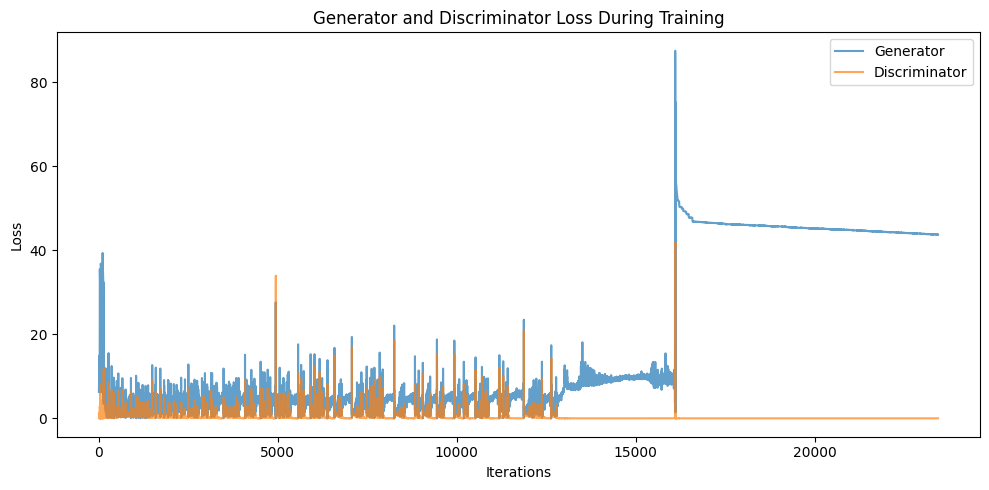

Loss curve saved.


In [10]:
plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="Generator",     alpha=0.7)
plt.plot(D_losses, label="Discriminator", alpha=0.7)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("generated_images/loss_curve.png", dpi=150)
plt.show()
print("Loss curve saved.")

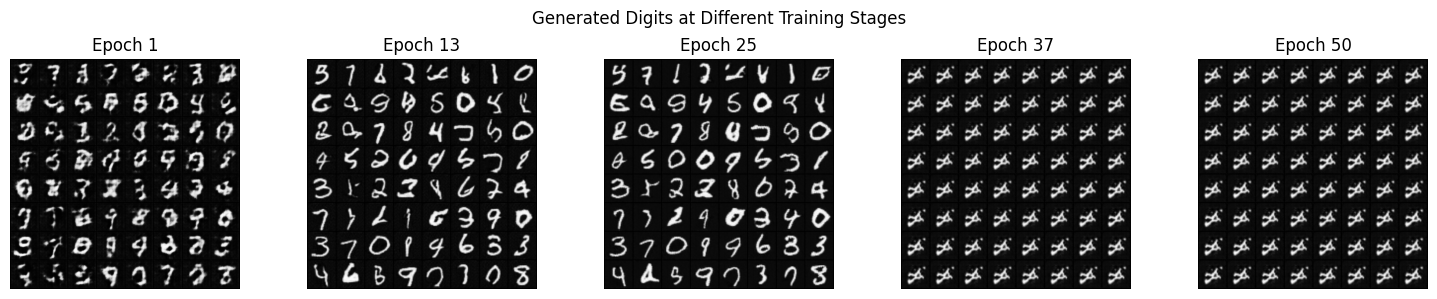

Training progression saved.


In [11]:
fig, axes = plt.subplots(1, min(5, len(img_list)),
                         figsize=(15, 3))
checkpoints = np.linspace(0, len(img_list) - 1, min(5, len(img_list)), dtype=int)
for ax, idx in zip(axes, checkpoints):
    ax.imshow(img_list[idx].permute(1, 2, 0).numpy(), cmap="gray")
    ax.set_title(f"Epoch {idx + 1}")
    ax.axis("off")
plt.suptitle("Generated Digits at Different Training Stages")
plt.tight_layout()
plt.savefig("generated_images/training_progression.png", dpi=150)
plt.show()
print("Training progression saved.")

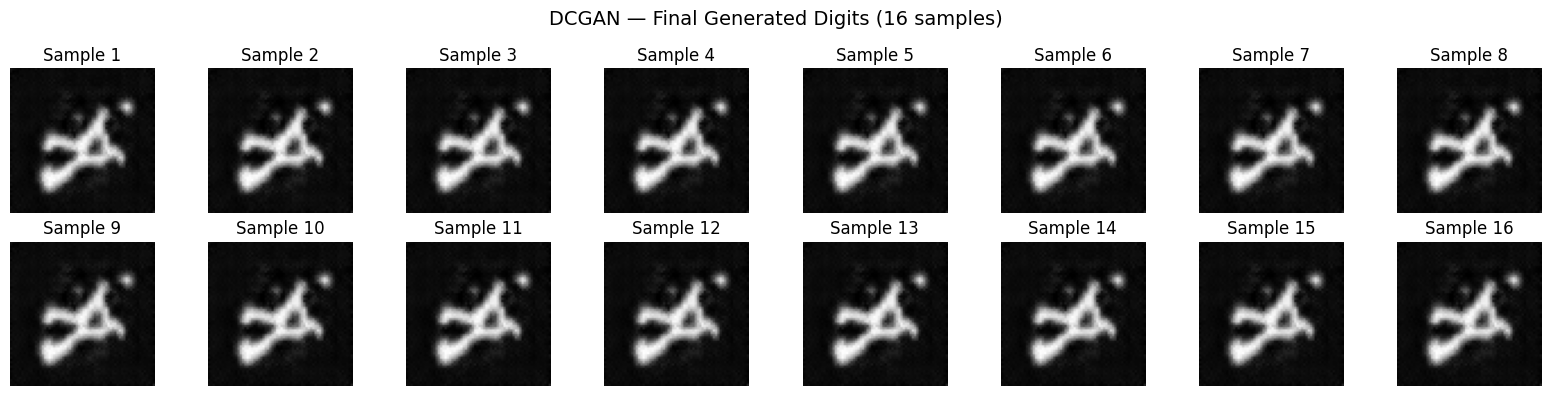

Final samples saved to generated_images/final_16_samples.png


In [12]:
noise_final = torch.randn(16, NZ, 1, 1, device=device)
with torch.no_grad():
    final_imgs = netG(noise_final).detach().cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for idx, ax in enumerate(axes.flatten()):
    img = final_imgs[idx].squeeze().numpy()
    img = (img * 0.5) + 0.5   # denormalise to [0,1]
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Sample {idx+1}")
    ax.axis("off")
plt.suptitle("DCGAN — Final Generated Digits (16 samples)", fontsize=14)
plt.tight_layout()
plt.savefig("generated_images/final_16_samples.png", dpi=150)
plt.show()
print("Final samples saved to generated_images/final_16_samples.png")

In [13]:
torch.save(netG.state_dict(), "generator.pth")
torch.save(netD.state_dict(), "discriminator.pth")
print("Model weights saved: generator.pth  /  discriminator.pth")

Model weights saved: generator.pth  /  discriminator.pth


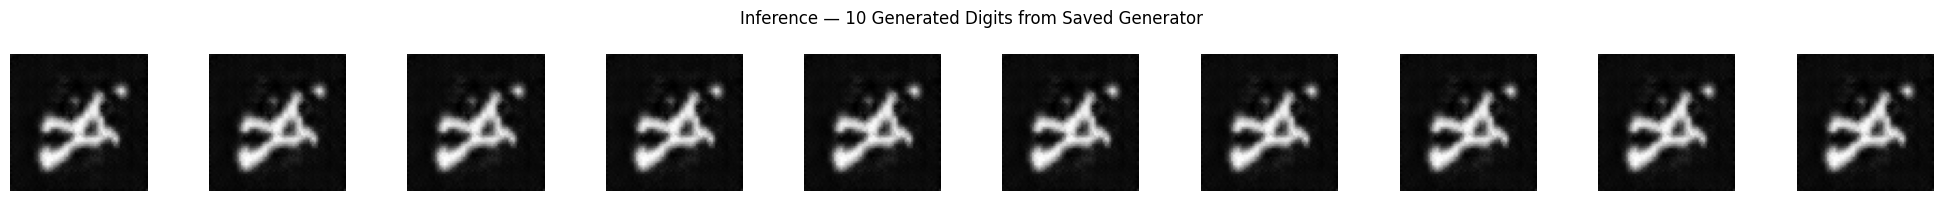

Inference demo complete. All done!


In [14]:

netG_loaded = Generator().to(device)
netG_loaded.load_state_dict(torch.load("generator.pth", map_location=device))
netG_loaded.eval()

demo_noise = torch.randn(10, NZ, 1, 1, device=device)
with torch.no_grad():
    demo_imgs = netG_loaded(demo_noise).detach().cpu()

fig, axes = plt.subplots(1, 10, figsize=(20, 2))
for idx, ax in enumerate(axes):
    img = demo_imgs[idx].squeeze().numpy()
    img = (img * 0.5) + 0.5
    ax.imshow(img, cmap="gray")
    ax.axis("off")
plt.suptitle("Inference — 10 Generated Digits from Saved Generator", fontsize=12)
plt.tight_layout()
plt.savefig("generated_images/inference_10_digits.png", dpi=150)
plt.show()
print("Inference demo complete. All done!")